# Replicating French, Schwert and Stambaugh (1987)

This notebook tries to reproduce the main results from *Expected Stock Returns and Volatility*.

I first explain the paper's idea, then calculate the main volatility measures and regressions, and finally compare my results with the paper.


## 1. What the paper is about

The main question is simple: **is stock-market volatility related to expected stock returns?**

The paper separates volatility into a predictable part and an unpredictable part. It then checks how each part is related to the market risk premium.

The calculations below follow the main equations in the paper, but the data are a public substitute for the original CRSP/S&P 500 data.


## 2. Data

The original paper used daily S&P 500 returns, the CRSP value-weighted market return, and the one-month T-bill rate.

I use the Fama/French market return and risk-free rate because the original CRSP data are not freely available.

This is close to the original data, but it is **not exactly the same data**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import skew as sk_skew
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (9, 4)

In [2]:
DATA_DIR = "data"

daily = pd.read_csv(f"{DATA_DIR}/ff_daily.csv", parse_dates=["date"], index_col="date") / 100.0
monthly = pd.read_csv(f"{DATA_DIR}/ff_monthly.csv", parse_dates=["date"], index_col="date") / 100.0
# data is stored in percent, so /100 gives decimal returns (0.01 = 1%)

# alternative: pull the data straight from French's website instead of the
# bundled csv (needs internet access, not run here)
# import pandas_datareader.data as web
# ff_d = web.DataReader("F-F_Research_Data_Factors_daily", "famafrench")[0] / 100.0
# ff_m = web.DataReader("F-F_Research_Data_Factors", "famafrench")[0] / 100.0
# daily = ff_d.assign(Mkt=ff_d["Mkt-RF"] + ff_d["RF"])
# monthly = ff_m.assign(Mkt=ff_m["Mkt-RF"] + ff_m["RF"])

print("Daily:", daily.index.min().date(), "to", daily.index.max().date(), f"({len(daily)} rows)")
print("Monthly:", monthly.index.min().date(), "to", monthly.index.max().date(), f"({len(monthly)} rows)")
daily.head(3)

Daily: 1926-11-03 to 2020-12-31 (24795 rows)
Monthly: 1927-01-01 to 2020-12-01 (1128 rows)


,Mkt,SMB,HML,UMD,RF
date,,,,,
1926-11-03,0.00213,-0.0024,-0.0028,0.0057,0.00013
1926-11-04,0.00603,-0.0015,0.0069,-0.0052,0.00013
1926-11-05,0.00083,-0.0009,0.0023,0.0115,0.00013


## 3. Methods

### Monthly volatility

I calculate monthly volatility from daily returns using the paper's equation (2). The calculation includes the autocovariance correction used by FSS.

### Predictable and unpredictable volatility

I fit an ARIMA(0,1,3) model to log volatility and use it to separate the predictable and unpredictable parts.

### Return regressions

I then regress the monthly excess return on the volatility measures using the same basic specifications as the paper.


## 4. Table 1 - volatility stats and ARIMA fit

Computing $\sigma_{mt}$ for the three periods FSS use (full sample + two subsamples), then fitting the ARIMA(0,1,3) model to each.

In [3]:
def monthly_sigma(daily_df, start, end, col="Mkt"):
    # eq. 2: monthly vol from daily returns, with the autocovariance correction
    d = daily_df.loc[start:end, [col]].copy()
    d["ym"] = d.index.to_period("M")

    def _sigma(r):
        r = r.values
        if len(r) < 2:
            return np.nan
        s2 = np.sum(r**2) + 2 * np.sum(r[:-1] * r[1:])
        if s2 <= 0:
            # can happen in months with big daily reversals - doesn't happen
            # here (1928-1984), but it does in the extension notebook (March 2020)
            s2 = np.sum(r**2)
        return np.sqrt(s2)

    s = d.groupby("ym")[col].apply(_sigma)
    s.index = s.index.to_timestamp()
    s.name = "sigma"
    return s


def arima_decompose(sigma):
    # eq. 3-4: ARIMA(0,1,3) on ln(sigma), then split into predictable/unpredictable
    ln_sigma = np.log(sigma)
    fit = ARIMA(ln_sigma, order=(0, 1, 3), trend="t").fit()
    fitted_ln = fit.fittedvalues.copy()
    fitted_ln.iloc[0] = np.nan  # first value isn't meaningful
    V = fit.resid.var()
    sigma_hat = np.exp(fitted_ln + 0.5 * V)
    sigma2_hat = np.exp(2 * fitted_ln + 2 * V)
    return fit, sigma_hat, sigma2_hat


def arima_coef_table(fit):
    # statsmodels flips the sign on the MA terms relative to the paper's theta_k
    p, se = fit.params, fit.bse
    out = {"theta0": (p.get("x1", np.nan), se.get("x1", np.nan))}
    for k in (1, 2, 3):
        out[f"theta{k}"] = (-p.get(f"ma.L{k}", np.nan), se.get(f"ma.L{k}", np.nan))
    return out

In [4]:
PERIODS = {
    "1928-1984": ("1928-01-01", "1984-12-31"),
    "1928-1952": ("1928-01-01", "1952-12-31"),
    "1953-1984": ("1953-01-01", "1984-12-31"),
}

sigma_by_period, arima_by_period = {}, {}
table1_rows = []
arima_rows = []

for label, (start, end) in PERIODS.items():
    sigma = monthly_sigma(daily, start, end)
    fit, sigma_hat, sigma2_hat = arima_decompose(sigma)
    sigma_by_period[label] = (sigma, sigma_hat, sigma2_hat)
    arima_by_period[label] = fit

    table1_rows.append({
        "Period": label, "N": len(sigma),
        "Mean": sigma.mean(), "Std.dev": sigma.std(ddof=1),
        "Skewness": sk_skew(sigma.dropna(), bias=False),
    })
    coefs = arima_coef_table(fit)
    arima_rows.append({
        "Period": label,
        **{f"{k} (coef)": v[0] for k, v in coefs.items()},
        **{f"{k} (se)": v[1] for k, v in coefs.items()},
    })

table1 = pd.DataFrame(table1_rows).set_index("Period").round(4)
arima_tab = pd.DataFrame(arima_rows).set_index("Period").round(4)
print("Table 1, Panel A - replicated")
table1

Table 1, Panel A - replicated


,N,Mean,Std.dev,Skewness
Period,,,,
1928-1984,684,0.0457,0.0315,2.9034
1928-1952,300,0.0573,0.0406,2.2183
1953-1984,384,0.0367,0.0172,1.7711


In [5]:
print("Table 1, Panel C - ARIMA(0,1,3) coefficients on ln(sigma_mt), replicated")
arima_tab[[c for c in arima_tab.columns if "coef" in c]]

Table 1, Panel C - ARIMA(0,1,3) coefficients on ln(sigma_mt), replicated


,theta0 (coef),theta1 (coef),theta2 (coef),theta3 (coef)
Period,,,,
1928-1984,-0.0001,0.5281,0.1588,0.0819
1928-1952,-0.0016,0.5396,0.2244,0.0032
1953-1984,0.0008,0.5214,0.0739,0.1808


**Comparison with the paper.** The main statistics are close to the numbers reported by FSS. Some differences are expected because I use the Fama/French market series instead of the exact original series.


## 5. Figure 1 - realized vs. predicted volatility

Same idea as FSS Figures 1a/1b: realized $\sigma_{mt}$ vs. the ARIMA-fitted $\hat\sigma_{mt}$ (should look a lot smoother).

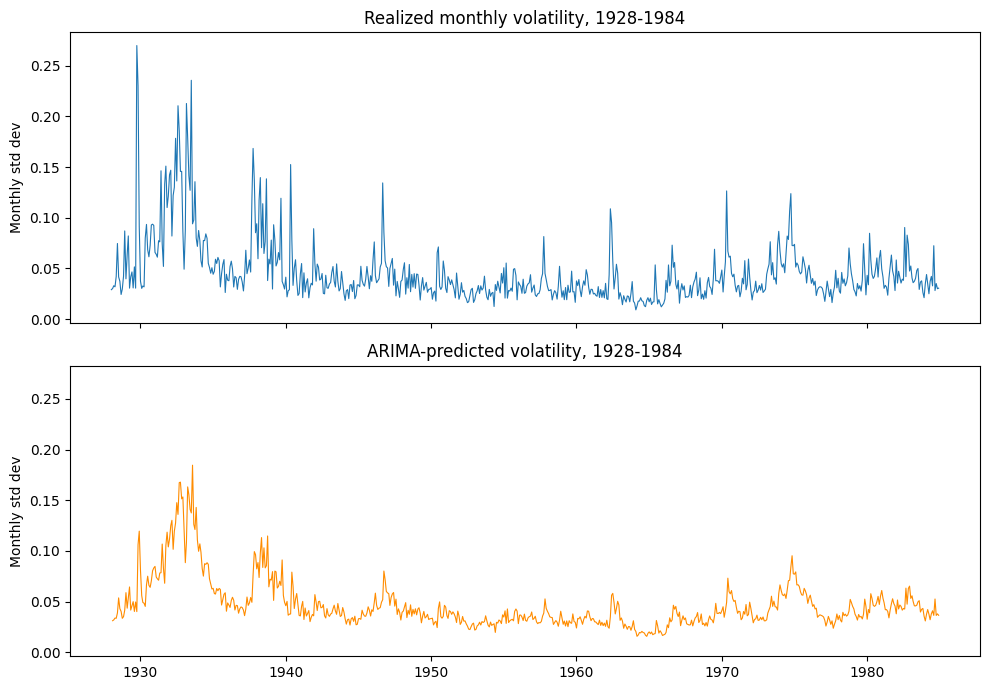

corr(sigma, sigma_hat) = 0.722  (paper reports 0.744)


In [6]:
sigma_full, sigma_hat_full, _ = sigma_by_period["1928-1984"]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, sharey=True)
axes[0].plot(sigma_full.index, sigma_full.values, lw=0.8)
axes[0].set_title("Realized monthly volatility, 1928-1984")
axes[1].plot(sigma_hat_full.index, sigma_hat_full.values, lw=0.8, color="darkorange")
axes[1].set_title("ARIMA-predicted volatility, 1928-1984")
for ax in axes:
    ax.set_ylabel("Monthly std dev")
plt.tight_layout()
plt.show()

print(f"corr(sigma, sigma_hat) = {sigma_full.corr(sigma_hat_full):.3f}  (paper reports 0.744)")

## 6. Table 3 - average risk premium

OLS mean and two WLS means (weighting by realized and by fitted volatility) of the monthly excess return.

In [7]:
def table3_stats(ex, sigma, sigma_hat):
    df = pd.DataFrame({"ex": ex, "sigma": sigma, "sigma_hat": sigma_hat}).dropna()
    ols = sm.OLS(df["ex"], np.ones(len(df))).fit()
    wls_actual = sm.WLS(df["ex"], np.ones(len(df)), weights=1.0 / df["sigma"]).fit()
    wls_pred = sm.WLS(df["ex"], np.ones(len(df)), weights=1.0 / df["sigma_hat"]).fit()
    return {
        "N": len(df),
        "OLS mean": ols.params.iloc[0], "OLS t": ols.tvalues.iloc[0],
        "WLS mean (actual sigma)": wls_actual.params.iloc[0], "WLS t (actual)": wls_actual.tvalues.iloc[0],
        "WLS mean (predicted sigma)": wls_pred.params.iloc[0], "WLS t (predicted)": wls_pred.tvalues.iloc[0],
        "Std.dev": df["ex"].std(ddof=1), "Skewness": sk_skew(df["ex"], bias=False),
    }

table3_rows = []
for label, (start, end) in PERIODS.items():
    sigma, sigma_hat, _ = sigma_by_period[label]
    ex = (monthly["Mkt"] - monthly["RF"]).loc[start:end]
    row = table3_stats(ex, sigma, sigma_hat)
    row["Period"] = label
    table3_rows.append(row)

table3 = pd.DataFrame(table3_rows).set_index("Period").round(4)
table3

,N,OLS mean,OLS t,WLS mean (actual sigma),WLS t (actual),WLS mean (predicted sigma),WLS t (predicted),Std.dev,Skewness
Period,,,,,,,,,
1928-1984,683,0.0060,2.6765,0.0096,5.9863,0.0056,3.0254,0.0588,0.4646
1928-1952,299,0.0076,1.7363,0.0130,4.3344,0.0076,2.1400,0.0752,0.4877
1953-1984,383,0.0048,2.2677,0.0077,4.3191,0.0045,2.2905,0.0418,-0.0986


**Comparison with the paper.** The OLS results are close to the original numbers. The WLS results differ somewhat, which is expected because the volatility series is not exactly the same as in the paper.


## 7. Table 4 - returns regressed on volatility

WLS of excess returns on predictable volatility (eq. 6) and on predictable + unpredictable volatility (eq. 7), for $p=1$ (std dev) and $p=2$ (variance). I report both plain WLS standard errors and robust (White) ones.

In [8]:
def fit_eq6_eq7(df, xcol, xucol):
    w = 1.0 / df[xcol] ** 2
    X6 = sm.add_constant(df[[xcol]])
    m6 = sm.WLS(df["ex"], X6, weights=w).fit()
    m6_robust = sm.WLS(df["ex"], X6, weights=w).fit(cov_type="HC0")
    X7 = sm.add_constant(df[[xcol, xucol]])
    m7 = sm.WLS(df["ex"], X7, weights=w).fit()
    m7_robust = sm.WLS(df["ex"], X7, weights=w).fit(cov_type="HC0")
    return m6, m6_robust, m7, m7_robust


def build_frame(label):
    sigma, sigma_hat, sigma2_hat = sigma_by_period[label]
    start, end = PERIODS[label]
    ex = (monthly["Mkt"] - monthly["RF"]).loc[start:end]
    df = pd.DataFrame({"ex": ex, "sigma": sigma, "sigma_hat": sigma_hat,
                        "sigma2": sigma ** 2, "sigma2_hat": sigma2_hat}).dropna()
    df["sigma_u"] = df["sigma"] - df["sigma_hat"]
    df["sigma2_u"] = df["sigma2"] - df["sigma2_hat"]
    return df


def fmt(coef, se, se_r):
    return f"{coef:.4f}  ({se:.4f})  [{se_r:.4f}]"


table4_rows = []
frames = {}
for label in PERIODS:
    df = build_frame(label)
    frames[label] = df
    for p, xcol, xucol in [(1, "sigma_hat", "sigma_u"), (2, "sigma2_hat", "sigma2_u")]:
        m6, m6r, m7, m7r = fit_eq6_eq7(df, xcol, xucol)
        table4_rows.append({
            "Period": label, "p": p,
            "alpha (eq.6)": fmt(m6.params["const"], m6.bse["const"], m6r.bse["const"]),
            "beta (eq.6)": fmt(m6.params[xcol], m6.bse[xcol], m6r.bse[xcol]),
            "alpha (eq.7)": fmt(m7.params["const"], m7.bse["const"], m7r.bse["const"]),
            "beta (eq.7)": fmt(m7.params[xcol], m7.bse[xcol], m7r.bse[xcol]),
            "gamma (eq.7)": fmt(m7.params[xucol], m7.bse[xucol], m7r.bse[xucol]),
            "R2 (eq.7)": round(m7.rsquared, 3),
        })

table4 = pd.DataFrame(table4_rows).set_index(["Period", "p"])
pd.set_option("display.max_colwidth", 40)
table4

alpha (eq.6)                  beta (eq.6)  \
Period    p                                                            
1928-1984 1  0.0042  (0.0045)  [0.0043]   0.0361  (0.1232)  [0.1172]   
          2  0.0041  (0.0021)  [0.0029]   0.8513  (1.7291)  [1.6761]   
1928-1952 1  0.0120  (0.0086)  [0.0087]  -0.0920  (0.1908)  [0.1858]   
          2  0.0082  (0.0046)  [0.0061]  -0.0130  (2.2768)  [2.0225]   
1953-1984 1  0.0031  (0.0059)  [0.0056]   0.0417  (0.1820)  [0.1656]   
          2  0.0047  (0.0027)  [0.0034]  -0.2695  (2.6740)  [2.4677]   

                           alpha (eq.7)                  beta (eq.7)  \
Period    p                                                            
1928-1984 1  0.0076  (0.0041)  [0.0040]  -0.0552  (0.1130)  [0.1126]   
          2  0.0046  (0.0019)  [0.0026]   0.6832  (1.6161)  [1.5266]   
1928-1952 1  0.0171  (0.0076)  [0.0082]  -0.2065  (0.1694)  [0.1849]   
          2  0.0101  (0.0041)  [0.0056]  -0.5764  (2.0179)  [1.8997]   
1953-1984 1  0.0079  (0.0056)  [0.0050]  -0.1170  (0.1720)  [0.1595]   
          2  0.0067  (0.0025)  [0.0027]  -2.6067  (2.4813)  [2.2331]   

                             gamma (eq.7)  R2 (eq.7)  
Period    p                                           
1928-1984 1   -1.0492  (0.0906)  [0.1186]      0.165  
          2   -5.5855  (0.5595)  [1.9219]      0.128  
1928-1952 1   -1.0382  (0.1142)  [0.1474]      0.219  
          2   -4.3114  (0.4748)  [1.2432]      0.218  
1953-1984 1   -1.0950  (0.1495)  [0.2003]      0.124  
          2  -13.9126  (1.6835)  [2.7141]      0.152

**Comparison with the paper.** The main coefficients have similar signs and broadly similar sizes. The results are not expected to match exactly because the data and software are different.


## 8. GARCH and GARCH-in-mean (Tables 2 & 5)

Fitting GARCH(2,1) (eq. 5e) and two GARCH-in-mean specs (eq. 8a with $\sigma_t$, eq. 8b with $\sigma_t^2$) on daily excess returns.

Quick note: GARCH fits much better numerically when returns are scaled to percent (e.g. 0.5 instead of 0.005), so I fit on percent-scale data and convert the coefficients back to decimal units afterward so they're comparable to the paper's numbers.

In [9]:
from arch.univariate import ARCHInMean, GARCH, ConstantMean

def daily_excess_pct(start, end):
    # percent-scale daily excess return - GARCH optimizer behaves much better this way
    d = daily.loc[start:end] * 100.0
    return d["Mkt"] - d["RF"]

garch_rows, garchm_rows = [], []
for label, (start, end) in PERIODS.items():
    ex_pct = daily_excess_pct(start, end)

    g = ConstantMean(ex_pct, volatility=GARCH(p=2, o=0, q=1)).fit(disp="off")
    garch_rows.append({
        "Period": label, "N": len(ex_pct),
        "a (omega)": g.params["omega"], "b (beta1)": g.params["beta[1]"],
        "c1 (alpha1)": g.params["alpha[1]"], "c2 (alpha2)": g.params["alpha[2]"],
        "persistence (alpha1+alpha2+beta1)": g.params["alpha[1]"] + g.params["alpha[2]"] + g.params["beta[1]"],
    })

    for form, name, scale in [("vol", "std.dev spec (8a)", 1.0), ("var", "variance spec (8b)", 100.0)]:
        gm = ARCHInMean(ex_pct, x=None, volatility=GARCH(p=2, o=0, q=1), form=form).fit(disp="off")
        beta_pct, se_pct = gm.params["kappa"], gm.std_err["kappa"]
        garchm_rows.append({
            "Period": label, "Spec": name,
            "alpha (decimal)": gm.params["Const"] / 100.0,
            "beta (decimal-equiv.)": beta_pct * scale,
            "se(beta, decimal-equiv.)": se_pct * scale,
            "t(beta)": beta_pct / se_pct,
        })

garch_tab = pd.DataFrame(garch_rows).set_index("Period").round(4)
garchm_tab = pd.DataFrame(garchm_rows).set_index(["Period", "Spec"]).round(4)
print("GARCH(2,1) on daily excess returns (percent scale) - eq. (5e)")
garch_tab

GARCH(2,1) on daily excess returns (percent scale) - eq. (5e)


,N,a (omega),b (beta1),c1 (alpha1),c2 (alpha2),persistence (alpha1+alpha2+beta1)
Period,,,,,,
1928-1984,15370,0.0107,0.8909,0.1005,0.0,0.9914
1928-1952,7327,0.0153,0.8773,0.1188,0.0,0.9960
1953-1984,8043,0.0104,0.8964,0.0858,0.0,0.9822


In [10]:
print("GARCH-in-mean - eq. (8a)/(8b)")
garchm_tab

GARCH-in-mean - eq. (8a)/(8b)


alpha (decimal)  beta (decimal-equiv.)  \
Period    Spec                                                         
1928-1984 std.dev spec (8a)           -0.0001                 0.0878   
          variance spec (8b)           0.0003                 2.9967   
1928-1952 std.dev spec (8a)            0.0003                 0.0514   
          variance spec (8b)           0.0006                 1.6771   
1953-1984 std.dev spec (8a)           -0.0004                 0.1418   
          variance spec (8b)           0.0001                 8.5292   

                              se(beta, decimal-equiv.)  t(beta)  
Period    Spec                                                   
1928-1984 std.dev spec (8a)                     0.0299   2.9332  
          variance spec (8b)                    1.0148   2.9530  
1928-1952 std.dev spec (8a)                     0.0298   1.7209  
          variance spec (8b)                    0.9417   1.7810  
1953-1984 std.dev spec (8a)                     0.0602   2.3537  
          variance spec (8b)                    3.2798   2.6005

**Comparison with the paper.** The GARCH results are broadly similar, but there are some important differences. The `arch` package imposes non-negative ARCH coefficients, so it cannot reproduce every coefficient in the original specification exactly.


## 9. What is replicated?

The project follows the main volatility calculation, ARIMA decomposition, return regressions, and GARCH specifications from the paper.

There are still some differences:
- I use Fama/French market data instead of the exact original data.
- The GARCH model does not include every feature of the original mean equation.
- The `arch` package places some restrictions on the GARCH coefficients.

So this should be viewed as a **student replication of the main results**, not an exact reproduction of every number in the paper.
